# Quickstart: NOAA MRMS CONUS analysis, hourly - dynamical.org Zarr

The NOAA Multi-Radar Multi-Sensor (MRMS) system integrates data from radar networks, satellites, and surface observations to produce high-resolution precipitation estimates across the continental United States.

This dataset provides hourly precipitation data at 0.01 degree (~1km) resolution from 2014 to present, transformed into a single analysis-ready Zarr store by [dynamical.org](https://dynamical.org).

Dataset documentation: https://dynamical.org/catalog/noaa-mrms-conus-analysis-hourly/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab or SageMaker Studio Lab, run this cell and then restart the notebook.
!uv pip install -q "xarray[complete]>=2025.3.0" "zarr>=3.0.8" requests aiohttp

In [2]:
import xarray as xr

ds = xr.open_zarr("https://data.dynamical.org/noaa/mrms/conus-analysis-hourly/latest.zarr", chunks=None)
ds

<xarray.Dataset> Size: 49TB
Dimensions:                                 (time: 99688, latitude: 3500,
                                             longitude: 7000)
Coordinates:
  * latitude                                (latitude) float64 28kB 54.99 ......
  * longitude                               (longitude) float64 56kB -130.0 ....
    spatial_ref                             int64 8B ...
  * time                                    (time) datetime64[ns] 798kB 2014-...
Data variables:
    categorical_precipitation_type_surface  (time, latitude, longitude) float32 10TB ...
    precipitation_pass_1_surface            (time, latitude, longitude) float32 10TB ...
    precipitation_pass_2_surface            (time, latitude, longitude) float32 10TB ...
    precipitation_radar_only_surface        (time, latitude, longitude) float32 10TB ...
    precipitation_surface                   (time, latitude, longitude) float32 10TB ...
Attributes:
    dataset_id:          noaa-mrms-conus-analysis-hourly
    dataset_version:     0.3.0
    name:                NOAA MRMS CONUS analysis, hourly
    description:         Hourly precipitation analysis from the Multi-Radar M...
    attribution:         NOAA NWS NCEP MRMS data processed by dynamical.org f...
    spatial_domain:      Continental United States
    spatial_resolution:  0.01 degrees (~1km)
    time_domain:         2014-11-01 00:00:00 UTC to Present
    time_resolution:     1 hour

The entire dataset is a single Zarr store that opens directly with xarray. Xarray is an open-source library for working with high-dimensional data like the 3D (time × latitude × longitude) dataset we have here.

We can use xarray to extract maps and time series from this dataset. Let's start with a time series and then make a map.

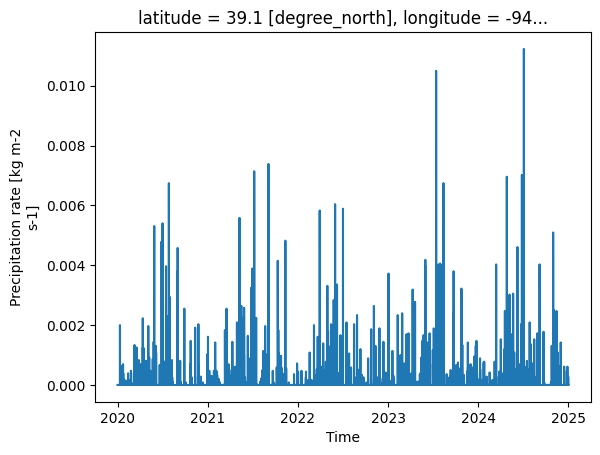

In [3]:
# Precipitation over time in Kansas City, MO
(
    ds["precipitation_surface"]
    .sel(latitude=39.1, longitude=-94.6, method="nearest")
    .sel(time=slice("2020", "2024"))
    .plot()
)

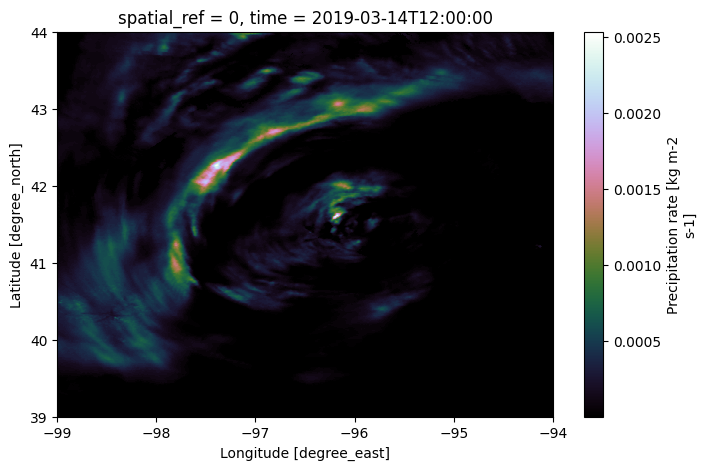

In [4]:
# Precipitation rate map in Nebraska, Winter Storm Ulmer, March 14, 2019
(
    ds["precipitation_surface"]
    .sel(
        latitude=slice(44, 39),
        longitude=slice(-99, -94),
        time="2019-03-14T12:00",
    )
    .plot(figsize=(8, 5), cmap="cubehelix")
)

### Which city had the most cumulative precipitation in 2025?

We can select point time series for several cities and compute cumulative precipitation to compare running totals of rain and snow over the year.

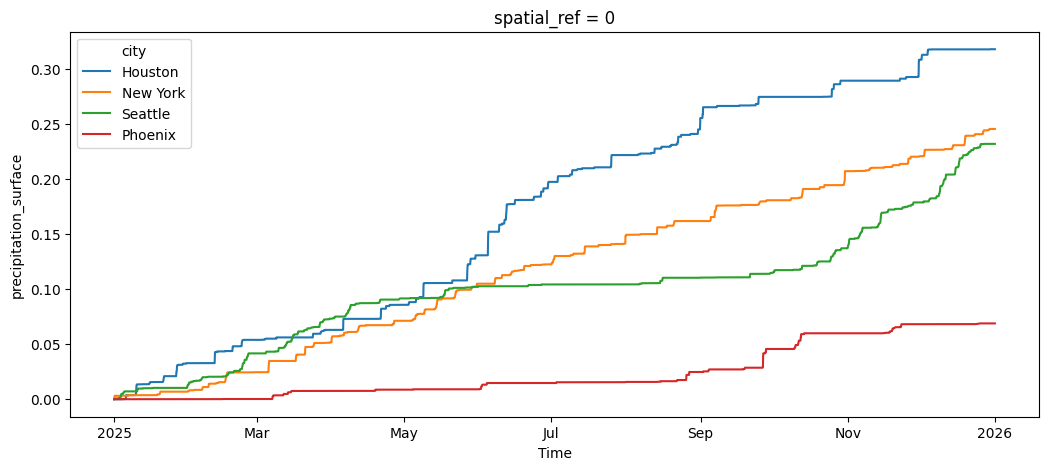

In [5]:
import pandas as pd

cities = pd.DataFrame([
    {"city": "Houston", "latitude": 29.76, "longitude": -95.37},
    {"city": "New York", "latitude": 40.71, "longitude": -74.01},
    {"city": "Seattle", "latitude": 47.61, "longitude": -122.33},
    {"city": "Phoenix", "latitude": 33.45, "longitude": -112.07},
]).set_index("city").to_xarray()

(
    ds["precipitation_surface"]
    .sel(time=slice("2025-01-01", "2025-12-31"))
    .sel(latitude=cities.latitude, longitude=cities.longitude, method="nearest")
    .cumsum(dim="time")
    .plot(hue="city", size=5, aspect=2.5)
)

### Where did it rain the most in the last week?

We can accumulate recent precipitation within a geographic area and find the pixel with the highest total. Here we look at the Southeast US.

In [6]:
now = pd.Timestamp.now()
week_ago = now - pd.Timedelta(days=7)
window_seconds = (now - week_ago).total_seconds()

recent_precipitation_rate = (
    ds["precipitation_surface"]
    .sel(latitude=slice(37, 30), longitude=slice(-92, -76)) # Southeast US: TN, NC, MS, AL, GA, SC
    .sel(time=slice(week_ago, now))
    .mean(dim="time")  # average rate at each pixel
    .load()
)

max_val = float(recent_precipitation_rate.max()) * window_seconds  # mm/s * seconds = total mm over the week
max_loc = recent_precipitation_rate.argmax(dim=["latitude", "longitude"])
max_lat = float(recent_precipitation_rate.latitude[max_loc["latitude"]])
max_lon = float(recent_precipitation_rate.longitude[max_loc["longitude"]])

print(f"Maximum last week precipitation accumulation: {max_val:.1f} mm at latitude: {max_lat:.2f}, longitude: {max_lon:.2f}")

Maximum last week precipitation accumulation: 177.3 mm at latitude: 33.05, longitude: -86.42


### Animated map

Let's visualize the 3D data as a map animated over time.

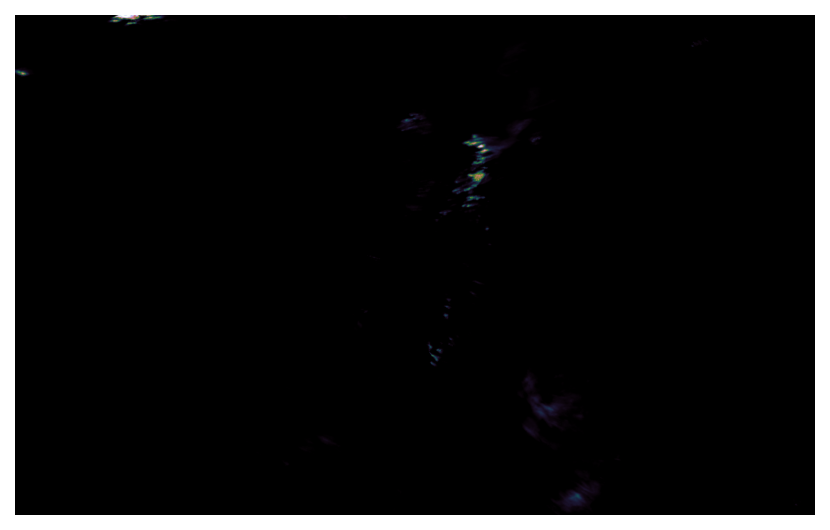

In [7]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

# Animation of the August 10, 2020 Midwest derecho sweeping across Iowa and Illinois

data = (
    ds["precipitation_surface"]
    .sel(
        time=slice("2020-08-10T06", "2020-08-11T12"),
        latitude=slice(45, 35),
        longitude=slice(-96, -80),
    )
    .load()
)

scale = 0.5
dpi = 150
fig, ax = plt.subplots(
    figsize=(data.longitude.size * scale / dpi, data.latitude.size * scale / dpi), dpi=dpi
)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.axis("off")

img = ax.imshow(data.isel(time=0), cmap="cubehelix", vmin=0, vmax=0.005)
anim = FuncAnimation(
    fig=fig, frames=data, func=lambda frame: img.set_data(frame), interval=120
)

HTML(anim.to_jshtml())

### Community challenge

With over a decade of hourly, ~1km precipitation data across the CONUS, there are many questions worth exploring.

Here are a few for inspiration:
- Are extreme precipitation events becoming more frequent? Identify grid cells where hours above a high threshold (e.g. 25 mm/hr) are increasing over time, and explore how this varies by region.
- Agricultural dependence on precipitation varies with irrigation methods. Combining this dataset with data from the USDA National Agricultural Statistics Service could reveal which counties' agricultural output is most sensitive to precipitation patterns.